# 06.1 — Análise do Ponto Operacional

Este notebook analisa o comportamento operacional dos quatro classificadores já ajustados no notebook `06_modelagem_comparativa.ipynb`.

## Objetivo

Investigar como o desempenho dos modelos se altera quando variamos:

- o **threshold de classificação**;
- a **cobertura operacional**;
- a proporção das reclamações priorizadas pelo modelo.

Serão analisadas:

- Precisão;
- Revocação;
- F1-score;
- quantidade de reclamações selecionadas;
- cobertura;
- Precision@k;
- Recall@k;
- Lift@k;
- ganhos acumulados.

## Regra metodológica

Este notebook **não retreina nenhum modelo** e **não altera hiperparâmetros**.

Os quatro pipelines já ajustados no período de treino são carregados do disco e aplicados exclusivamente ao período intermediário utilizado para avaliação operacional.

O conjunto **out-of-time (OOT)** permanece completamente isolado.

A finalidade deste notebook não é escolher automaticamente um threshold, mas produzir evidências que permitam definir um ponto operacional coerente com a capacidade e os objetivos do negócio.


## 1. Bibliotecas e configurações


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from IPython.display import display

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## 2. Diretórios, base e modelos ajustados


In [2]:
PROJECT_DIR = Path(r"C:\UnB\script_md")

PROCESSADOS_DIR = PROJECT_DIR / "Base de dados" / "processados"
MODELS_DIR = PROJECT_DIR / "outputs" / "modelos"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figuras"
TABLES_DIR = PROJECT_DIR / "outputs" / "tabelas"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

INPUT_FILE = PROCESSADOS_DIR / "dataset_modelagem_preparado.csv"

ARQUIVOS_MODELOS = {
    "Regressão Logística": MODELS_DIR / "modelo_treino_regressao_logistica.joblib",
    "KNN": MODELS_DIR / "modelo_treino_knn.joblib",
    "Random Forest": MODELS_DIR / "modelo_treino_random_forest.joblib",
    "Gradient Boosting": MODELS_DIR / "modelo_treino_gradient_boosting.joblib"
}

if not INPUT_FILE.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado: {INPUT_FILE}. "
        "Execute primeiro o notebook 03_preparacao_dados.ipynb."
    )

for nome, caminho in ARQUIVOS_MODELOS.items():
    if not caminho.exists():
        raise FileNotFoundError(
            f"Modelo não encontrado: {caminho}. "
            "Execute primeiro o notebook 06_modelagem_comparativa.ipynb."
        )

df = pd.read_csv(
    INPUT_FILE,
    sep=";",
    encoding="utf-8-sig",
    low_memory=False
)

modelos = {
    nome: joblib.load(caminho)
    for nome, caminho in ARQUIVOS_MODELOS.items()
}

print(f"Base carregada: {len(df):,} registros")
print(f"Modelos carregados: {len(modelos)}")


Base carregada: 58,131 registros
Modelos carregados: 4


## 3. Período operacional analisado

O conjunto utilizado nesta etapa corresponde aos 12 meses intermediários já empregados na comparação inicial dos modelos.

Como ele passa a subsidiar a definição do ponto operacional, metodologicamente deverá ser interpretado como **conjunto de teste/validação operacional**.

O OOT continuará reservado para a avaliação final.


In [3]:
PREDITORES = [
    "Região",
    "UF",
    "Cidade",
    "Sexo",
    "Faixa Etária",
    "Área",
    "Assunto",
    "Grupo Problema",
    "Problema",
    "Como Comprou Contratou",
    "Procurou Empresa"
]

TARGET = "target"

df_operacional = (
    df[df["Amostra"] == "Teste"]
    .sort_values("AAAA_MM")
    .reset_index(drop=True)
)

n_oot_reservado = int(
    (df["Amostra"] == "OOT").sum()
)

y_operacional = (
    df_operacional[TARGET]
    .astype(int)
    .copy()
)

prevalencia = y_operacional.mean()

print(f"Período analisado: {df_operacional['AAAA_MM'].min()} a {df_operacional['AAAA_MM'].max()}")
print(f"Registros: {len(df_operacional):,}")
print(f"Prevalência de Resolvida: {prevalencia * 100:.2f}%")
print(f"OOT reservado e não utilizado: {n_oot_reservado:,} registros")


Período analisado: 2024_08 a 2025_07
Registros: 14,027
Prevalência de Resolvida: 38.46%
OOT reservado e não utilizado: 32,072 registros


## 4. Identificação automática das features esperadas por cada pipeline

O KNN pode ter sido selecionado com ou sem `Cidade`. Para evitar reconstruir manualmente essa decisão, o notebook identifica as colunas utilizadas pelo pipeline ajustado.


In [4]:
def obter_features_modelo(modelo, features_padrao):
    steps = modelo.named_steps

    if "codificacao" in steps:
        transformador = steps["codificacao"]
        if hasattr(transformador, "feature_names_in_"):
            return list(transformador.feature_names_in_)

    if "preprocessamento" in steps:
        transformador = steps["preprocessamento"]
        if hasattr(transformador, "feature_names_in_"):
            return list(transformador.feature_names_in_)

    return list(features_padrao)


features_por_modelo = {
    nome: obter_features_modelo(modelo, PREDITORES)
    for nome, modelo in modelos.items()
}

for nome, features in features_por_modelo.items():
    print(f"{nome}: {len(features)} atributos")
    print(features)
    print()


Regressão Logística: 11 atributos
['Região', 'UF', 'Cidade', 'Sexo', 'Faixa Etária', 'Área', 'Assunto', 'Grupo Problema', 'Problema', 'Como Comprou Contratou', 'Procurou Empresa']

KNN: 10 atributos
['Região', 'UF', 'Sexo', 'Faixa Etária', 'Área', 'Assunto', 'Grupo Problema', 'Problema', 'Como Comprou Contratou', 'Procurou Empresa']

Random Forest: 11 atributos
['Região', 'UF', 'Cidade', 'Sexo', 'Faixa Etária', 'Área', 'Assunto', 'Grupo Problema', 'Problema', 'Como Comprou Contratou', 'Procurou Empresa']

Gradient Boosting: 11 atributos
['Região', 'UF', 'Cidade', 'Sexo', 'Faixa Etária', 'Área', 'Assunto', 'Grupo Problema', 'Problema', 'Como Comprou Contratou', 'Procurou Empresa']



## 5. Probabilidades previstas no período operacional


In [5]:
probabilidades = {}

for nome, modelo in modelos.items():
    features = features_por_modelo[nome]

    X = df_operacional[features].copy()

    probabilidades[nome] = (
        modelo.predict_proba(X)[:, 1]
    )

    print(
        f"{nome}: probabilidades calculadas para "
        f"{len(probabilidades[nome]):,} observações."
    )


Regressão Logística: probabilidades calculadas para 14,027 observações.
KNN: probabilidades calculadas para 14,027 observações.
Random Forest: probabilidades calculadas para 14,027 observações.
Gradient Boosting: probabilidades calculadas para 14,027 observações.


## 6. Análise por threshold

O threshold determina a partir de qual probabilidade estimada uma reclamação será classificada como `Resolvida`.

Para cada valor entre `0,05` e `0,95`, são calculados:

- Precisão;
- Revocação;
- F1-score;
- número de reclamações selecionadas;
- cobertura operacional.

A cobertura corresponde a:

\[
Coverage = \frac{N_{selecionadas}}{N_{total}}
\]

Nenhum threshold será selecionado automaticamente.


In [6]:
thresholds = np.round(
    np.arange(0.05, 0.951, 0.01),
    2
)

linhas_threshold = []

for nome, prob in probabilidades.items():
    for threshold in thresholds:
        pred = (
            prob >= threshold
        ).astype(int)

        selecionadas = int(
            pred.sum()
        )

        cobertura = (
            selecionadas / len(pred)
            if len(pred) > 0
            else 0
        )

        linhas_threshold.append({
            "Modelo": nome,
            "Threshold": threshold,
            "Precisão": precision_score(
                y_operacional,
                pred,
                zero_division=0
            ),
            "Revocação": recall_score(
                y_operacional,
                pred,
                zero_division=0
            ),
            "F1-score": f1_score(
                y_operacional,
                pred,
                zero_division=0
            ),
            "Selecionadas": selecionadas,
            "Cobertura": cobertura
        })

resultados_threshold = pd.DataFrame(
    linhas_threshold
)

display(
    resultados_threshold.head(20)
)

resultados_threshold.to_csv(
    TABLES_DIR / "operacional_metricas_por_threshold.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


,Modelo,Threshold,Precisão,Revocação,F1-score,Selecionadas,Cobertura
0,Regressão Logística,0.0500,0.3846,1.0000,0.5556,14027,1.0000
1,Regressão Logística,0.0600,0.3846,1.0000,0.5556,14027,1.0000
2,Regressão Logística,0.0700,0.3846,1.0000,0.5556,14027,1.0000
3,Regressão Logística,0.0800,0.3846,1.0000,0.5556,14027,1.0000
4,Regressão Logística,0.0900,0.3846,1.0000,0.5556,14026,0.9999
5,Regressão Logística,0.1000,0.3846,1.0000,0.5556,14026,0.9999
6,Regressão Logística,0.1100,0.3847,0.9998,0.5556,14023,0.9997
7,Regressão Logística,0.1200,0.3847,0.9998,0.5556,14021,0.9996
8,Regressão Logística,0.1300,0.3847,0.9996,0.5556,14019,0.9994
9,Regressão Logística,0.1400,0.3850,0.9994,0.5558,14006,0.9985


## 7. Pontos de referência de threshold

Para facilitar a leitura, são apresentados alguns thresholds de referência.

Esses valores não constituem escolha automática do ponto operacional.


In [7]:
thresholds_referencia = [
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80
]

tabela_thresholds_referencia = (
    resultados_threshold[
        resultados_threshold["Threshold"].isin(
            thresholds_referencia
        )
    ]
    .copy()
)

tabela_thresholds_referencia["Cobertura (%)"] = (
    tabela_thresholds_referencia["Cobertura"] * 100
)

display(
    tabela_thresholds_referencia[
        [
            "Modelo",
            "Threshold",
            "Precisão",
            "Revocação",
            "F1-score",
            "Selecionadas",
            "Cobertura (%)"
        ]
    ].round(4)
)

tabela_thresholds_referencia.to_csv(
    TABLES_DIR / "operacional_thresholds_referencia.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


,Modelo,Threshold,Precisão,Revocação,F1-score,Selecionadas,Cobertura (%)
25,Regressão Logística,0.3000,0.4312,0.9014,0.5833,11279,80.4092
35,Regressão Logística,0.4000,0.4783,0.7310,0.5783,8246,58.7866
45,Regressão Logística,0.5000,0.5305,0.4780,0.5029,4861,34.6546
55,Regressão Logística,0.6000,0.5830,0.2532,0.3531,2343,16.7035
65,Regressão Logística,0.7000,0.6304,0.0816,0.1444,698,4.9761
75,Regressão Logística,0.8000,0.6604,0.0065,0.0128,53,0.3778
116,KNN,0.3000,0.4255,0.8786,0.5733,11141,79.4254
126,KNN,0.4000,0.4582,0.6923,0.5515,8151,58.1094
136,KNN,0.5000,0.5032,0.4458,0.4728,4779,34.0700
146,KNN,0.6000,0.5596,0.2221,0.3179,2141,15.2634


## 8. Curvas Precision, Recall e Cobertura por threshold

Um gráfico é gerado para cada modelo, permitindo visualizar o trade-off entre:

- confiança entre os casos selecionados;
- proporção de casos positivos recuperados;
- volume operacional selecionado.


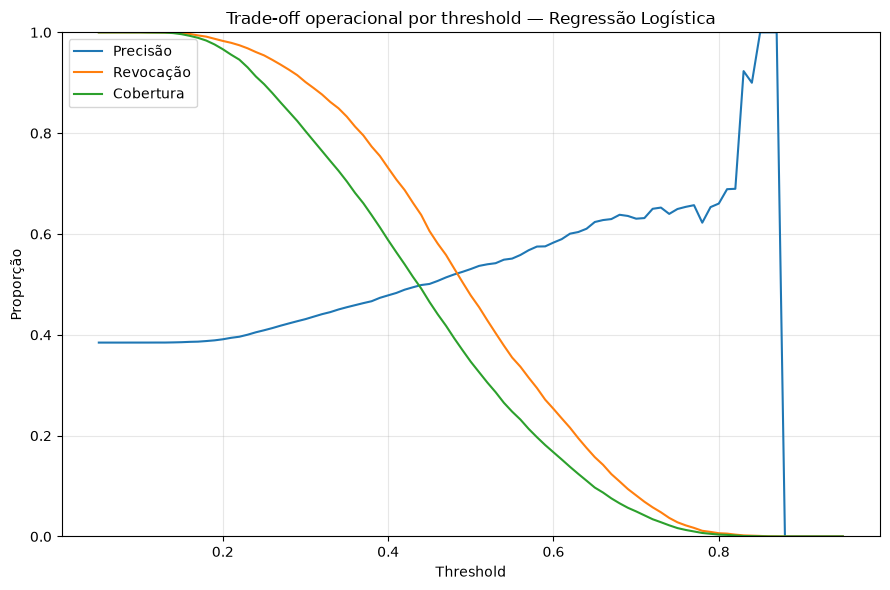

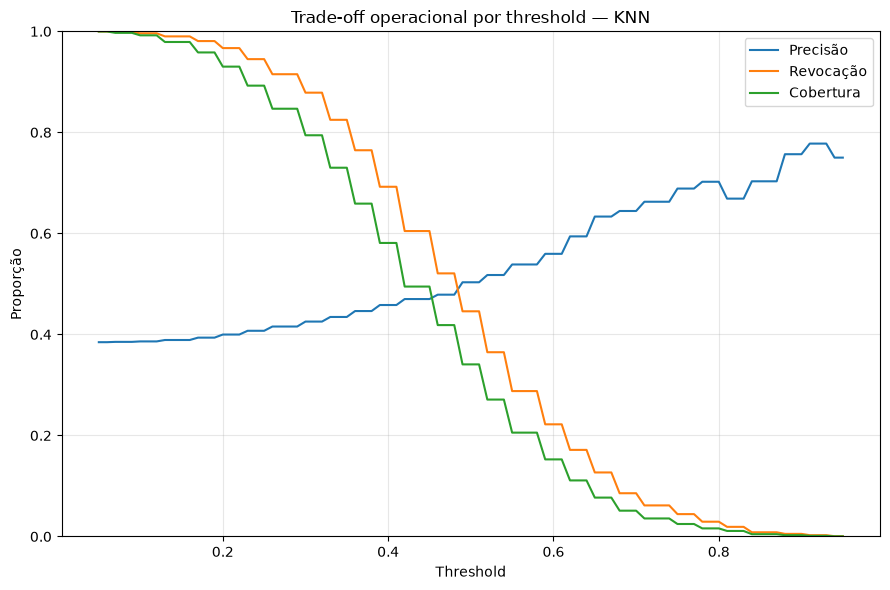

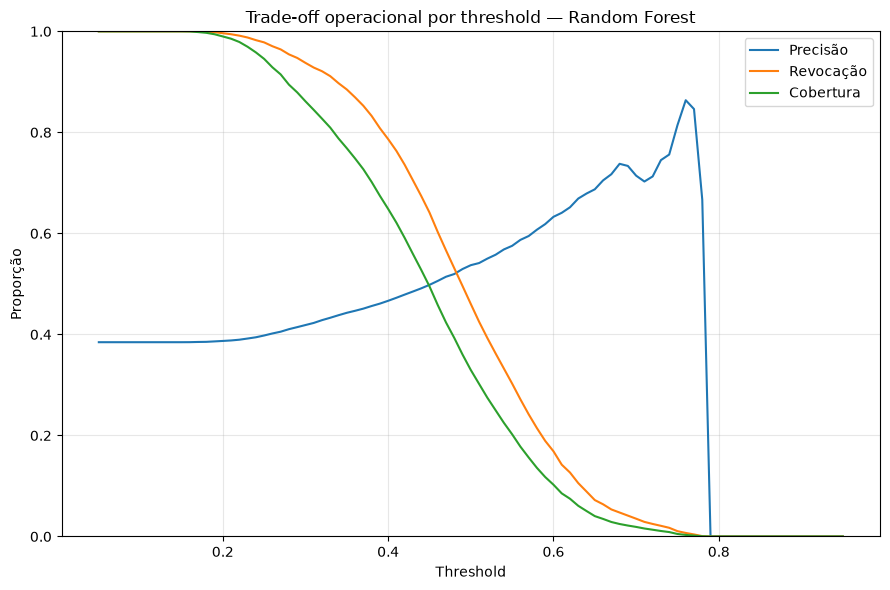

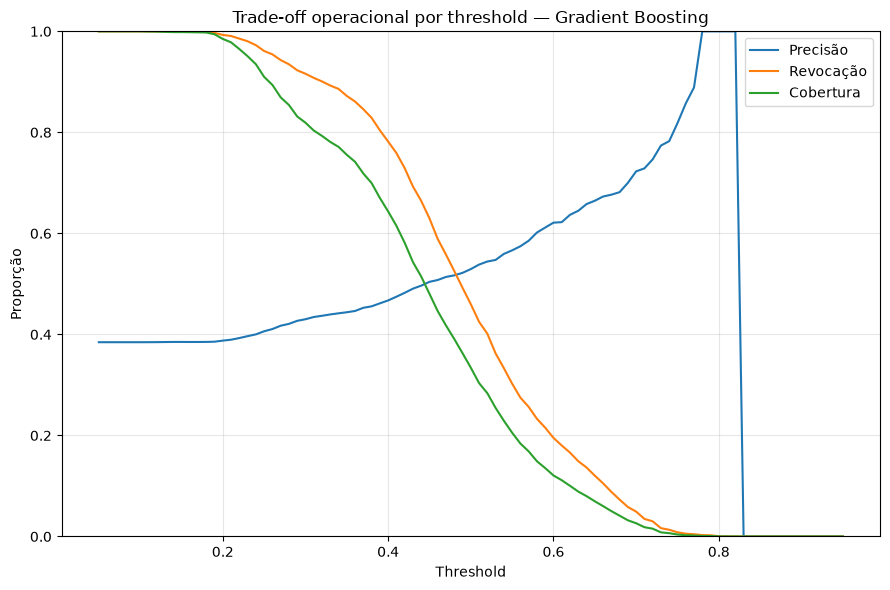

In [8]:
for nome in modelos.keys():
    dados = (
        resultados_threshold[
            resultados_threshold["Modelo"] == nome
        ]
        .copy()
    )

    fig, ax = plt.subplots(
        figsize=(9, 6)
    )

    ax.plot(
        dados["Threshold"],
        dados["Precisão"],
        label="Precisão"
    )

    ax.plot(
        dados["Threshold"],
        dados["Revocação"],
        label="Revocação"
    )

    ax.plot(
        dados["Threshold"],
        dados["Cobertura"],
        label="Cobertura"
    )

    ax.set_title(
        f"Trade-off operacional por threshold — {nome}"
    )

    ax.set_xlabel("Threshold")
    ax.set_ylabel("Proporção")
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()

    nome_arquivo = (
        nome.lower()
        .replace(" ", "_")
        .replace("ã", "a")
        .replace("ç", "c")
        .replace("ó", "o")
        .replace("í", "i")
    )

    plt.savefig(
        FIGURES_DIR /
        f"operacional_threshold_{nome_arquivo}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


## 9. Precision@k, Recall@k e Lift@k

A análise baseada em ranking responde a uma pergunta operacional diferente:

> Se a instituição puder atuar apenas sobre uma determinada proporção das reclamações, qual será a concentração de casos efetivamente resolvidos nesse grupo?

Para cada percentual `k`, são selecionadas as reclamações com maiores probabilidades estimadas.

São calculados:

### Precision@k

\[
Precision@k =
\frac{\text{Resolvidas no Top-k}}
{\text{Reclamações no Top-k}}
\]

### Recall@k

\[
Recall@k =
\frac{\text{Resolvidas no Top-k}}
{\text{Total de Resolvidas}}
\]

### Lift@k

\[
Lift@k =
\frac{Precision@k}
{\text{Prevalência da classe positiva}}
\]

O Lift mostra quantas vezes o grupo priorizado concentra mais reclamações resolvidas do que a população geral.


In [9]:
percentuais_k = [
    0.05,
    0.10,
    0.20,
    0.30,
    0.50
]

linhas_topk = []

total_positivos = int(
    y_operacional.sum()
)

for nome, prob in probabilidades.items():
    ordem = np.argsort(
        -prob
    )

    y_ordenado = (
        y_operacional
        .to_numpy()[ordem]
    )

    for k in percentuais_k:
        n_top = int(
            np.ceil(
                len(y_ordenado) * k
            )
        )

        y_top = y_ordenado[:n_top]

        positivos_top = int(
            y_top.sum()
        )

        precision_k = (
            positivos_top / n_top
            if n_top > 0
            else 0
        )

        recall_k = (
            positivos_top / total_positivos
            if total_positivos > 0
            else 0
        )

        lift_k = (
            precision_k / prevalencia
            if prevalencia > 0
            else np.nan
        )

        linhas_topk.append({
            "Modelo": nome,
            "Top (%)": k * 100,
            "Selecionadas": n_top,
            "Resolvidas no Top": positivos_top,
            "Precision@k": precision_k,
            "Recall@k": recall_k,
            "Lift@k": lift_k
        })

resultados_topk = pd.DataFrame(
    linhas_topk
)

display(
    resultados_topk.round(4)
)

resultados_topk.to_csv(
    TABLES_DIR / "operacional_precision_recall_lift_topk.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


,Modelo,Top (%),Selecionadas,Resolvidas no Top,Precision@k,Recall@k,Lift@k
0,Regressão Logística,5.0000,702,443,0.6311,0.0821,1.6407
1,Regressão Logística,10.0000,1403,874,0.6230,0.1620,1.6197
2,Regressão Logística,20.0000,2806,1608,0.5731,0.2981,1.4900
3,Regressão Logística,30.0000,4209,2278,0.5412,0.4222,1.4072
4,Regressão Logística,50.0000,7014,3489,0.4974,0.6467,1.2933
5,KNN,5.0000,702,452,0.6439,0.0838,1.6741
6,KNN,10.0000,1403,850,0.6058,0.1576,1.5752
7,KNN,20.0000,2806,1514,0.5396,0.2806,1.4029
8,KNN,30.0000,4209,2144,0.5094,0.3974,1.3244
9,KNN,50.0000,7014,3296,0.4699,0.6109,1.2218


## 10. Comparação de Precision@k

Este gráfico permite comparar diretamente a concentração de reclamações resolvidas nos grupos de maior probabilidade estimada.


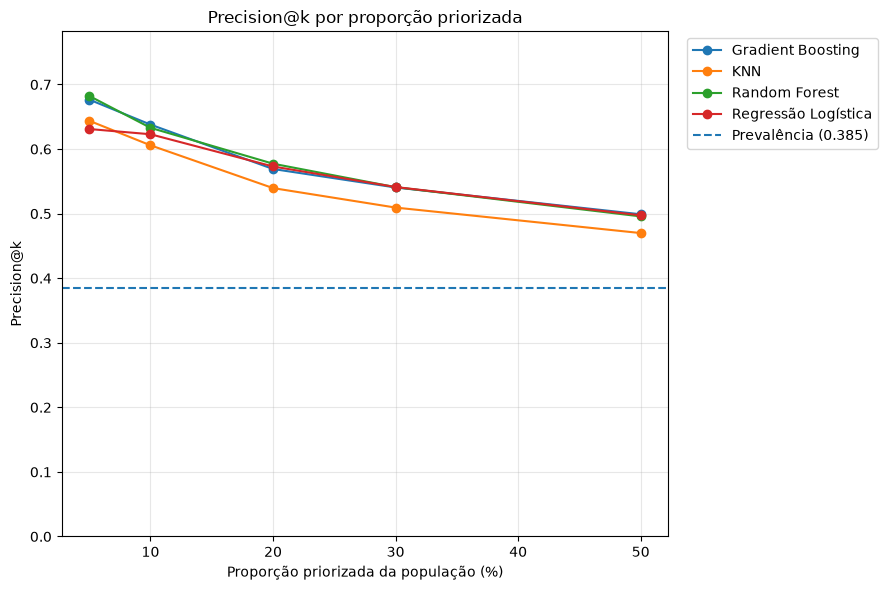

In [10]:
tabela_precision_k = (
    resultados_topk
    .pivot(
        index="Top (%)",
        columns="Modelo",
        values="Precision@k"
    )
)

ax = tabela_precision_k.plot(
    marker="o",
    figsize=(9, 6)
)

ax.axhline(
    prevalencia,
    linestyle="--",
    label=f"Prevalência ({prevalencia:.3f})"
)

ax.set_title(
    "Precision@k por proporção priorizada"
)

ax.set_xlabel(
    "Proporção priorizada da população (%)"
)

ax.set_ylabel(
    "Precision@k"
)

ax.set_ylim(
    0,
    min(
        1,
        max(
            0.1,
            tabela_precision_k.max().max() + 0.1
        )
    )
)

ax.grid(alpha=0.3)
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "operacional_precision_at_k.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 11. Comparação de Lift@k


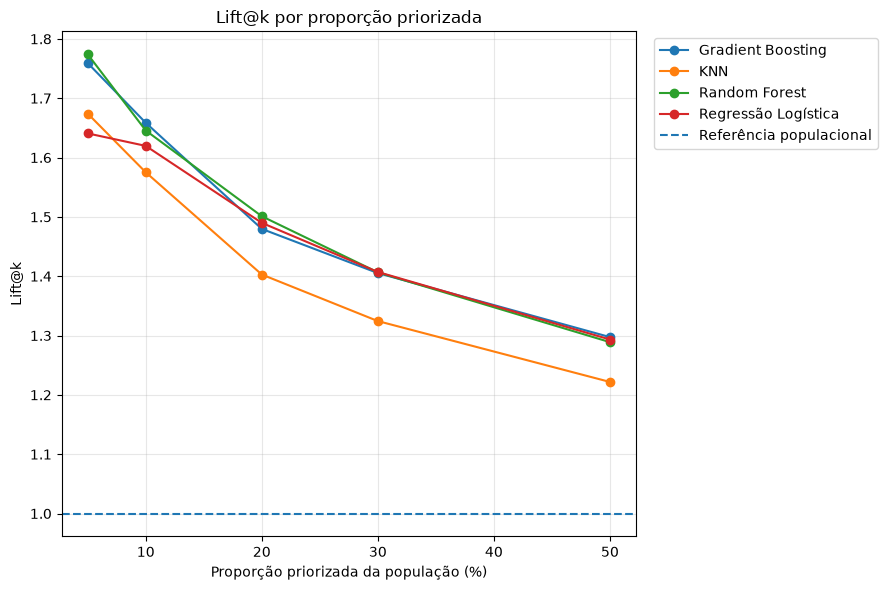

In [11]:
tabela_lift_k = (
    resultados_topk
    .pivot(
        index="Top (%)",
        columns="Modelo",
        values="Lift@k"
    )
)

ax = tabela_lift_k.plot(
    marker="o",
    figsize=(9, 6)
)

ax.axhline(
    1,
    linestyle="--",
    label="Referência populacional"
)

ax.set_title(
    "Lift@k por proporção priorizada"
)

ax.set_xlabel(
    "Proporção priorizada da população (%)"
)

ax.set_ylabel(
    "Lift@k"
)

ax.grid(alpha=0.3)
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "operacional_lift_at_k.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 12. Curva de ganhos acumulados

A curva de ganhos mostra qual proporção das reclamações efetivamente resolvidas é capturada ao percorrer a população da maior para a menor probabilidade prevista.


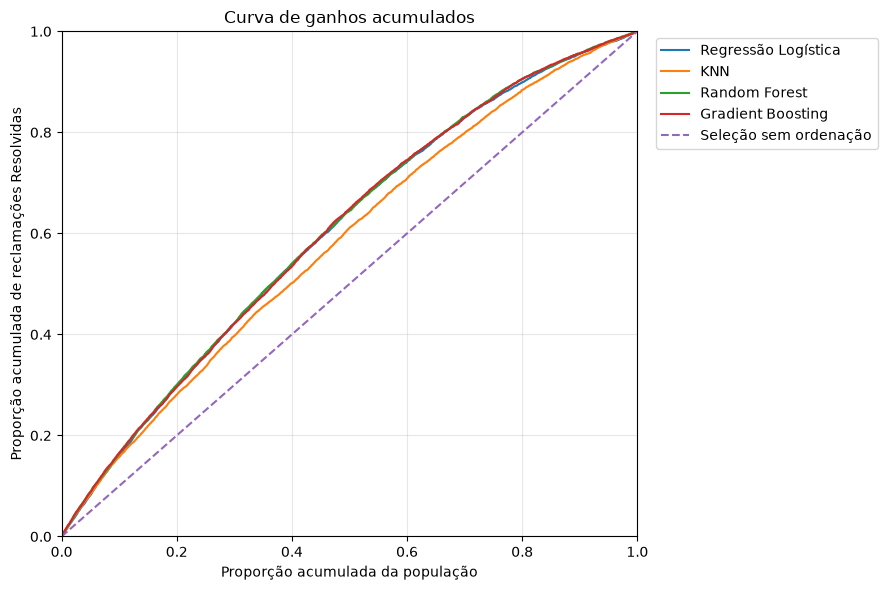

In [12]:
fig, ax = plt.subplots(
    figsize=(9, 6)
)

for nome, prob in probabilidades.items():
    ordem = np.argsort(
        -prob
    )

    y_ordenado = (
        y_operacional
        .to_numpy()[ordem]
    )

    positivos_acumulados = (
        np.cumsum(y_ordenado)
    )

    ganho_acumulado = (
        positivos_acumulados /
        positivos_acumulados[-1]
    )

    populacao_acumulada = (
        np.arange(
            1,
            len(y_ordenado) + 1
        ) /
        len(y_ordenado)
    )

    ax.plot(
        populacao_acumulada,
        ganho_acumulado,
        label=nome
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Seleção sem ordenação"
)

ax.set_title(
    "Curva de ganhos acumulados"
)

ax.set_xlabel(
    "Proporção acumulada da população"
)

ax.set_ylabel(
    "Proporção acumulada de reclamações Resolvidas"
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "operacional_ganhos_acumulados.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 13. Quadro operacional para discussão com especialistas

Este quadro concentra os resultados dos pontos de capacidade operacional de 5%, 10%, 20%, 30% e 50%.

Ele pode ser utilizado na discussão com especialistas da área de negócio para responder questões como:

- qual proporção das reclamações poderia ser tratada proativamente;
- qual Precision seria operacionalmente útil;
- qual perda de Recall seria aceitável em troca de maior concentração de casos resolvíveis.

Nenhum modelo ou ponto operacional é selecionado automaticamente neste notebook.


In [13]:
quadro_especialistas = (
    resultados_topk[
        [
            "Modelo",
            "Top (%)",
            "Selecionadas",
            "Precision@k",
            "Recall@k",
            "Lift@k"
        ]
    ]
    .copy()
)

display(
    quadro_especialistas.round(4)
)

quadro_especialistas.to_csv(
    TABLES_DIR / "operacional_quadro_especialistas.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


,Modelo,Top (%),Selecionadas,Precision@k,Recall@k,Lift@k
0,Regressão Logística,5.0000,702,0.6311,0.0821,1.6407
1,Regressão Logística,10.0000,1403,0.6230,0.1620,1.6197
2,Regressão Logística,20.0000,2806,0.5731,0.2981,1.4900
3,Regressão Logística,30.0000,4209,0.5412,0.4222,1.4072
4,Regressão Logística,50.0000,7014,0.4974,0.6467,1.2933
5,KNN,5.0000,702,0.6439,0.0838,1.6741
6,KNN,10.0000,1403,0.6058,0.1576,1.5752
7,KNN,20.0000,2806,0.5396,0.2806,1.4029
8,KNN,30.0000,4209,0.5094,0.3974,1.3244
9,KNN,50.0000,7014,0.4699,0.6109,1.2218


## 14. Comparação com o threshold padrão de 0,50

Este bloco preserva a ligação com a análise do notebook 06 e permite comparar o ponto convencional de `0,50` com as análises baseadas em capacidade operacional.


In [14]:
resultado_threshold_050 = (
    resultados_threshold[
        resultados_threshold["Threshold"] == 0.50
    ]
    .copy()
)

resultado_threshold_050["Cobertura (%)"] = (
    resultado_threshold_050["Cobertura"] * 100
)

display(
    resultado_threshold_050[
        [
            "Modelo",
            "Threshold",
            "Precisão",
            "Revocação",
            "F1-score",
            "Selecionadas",
            "Cobertura (%)"
        ]
    ].round(4)
)

resultado_threshold_050.to_csv(
    TABLES_DIR / "operacional_threshold_050.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


,Modelo,Threshold,Precisão,Revocação,F1-score,Selecionadas,Cobertura (%)
45,Regressão Logística,0.5000,0.5305,0.4780,0.5029,4861,34.6546
136,KNN,0.5000,0.5032,0.4458,0.4728,4779,34.0700
227,Random Forest,0.5000,0.5371,0.4602,0.4957,4623,32.9579
318,Gradient Boosting,0.5000,0.5293,0.4599,0.4922,4687,33.4141


## 15. Síntese automática

A síntese abaixo descreve os resultados sem escolher um ponto operacional final.


In [15]:
print(
    f"A prevalência da classe Resolvida no período de validação operacional foi de "
    f"{prevalencia * 100:.2f}%. "
    "Os resultados de Precision@k e Lift@k devem ser interpretados em relação a essa "
    "taxa de referência."
)

print()

for k in percentuais_k:
    recorte = (
        resultados_topk[
            resultados_topk["Top (%)"] == k * 100
        ]
        .sort_values(
            "Precision@k",
            ascending=False
        )
    )

    linha = recorte.iloc[0]

    print(
        f"No Top {k * 100:.0f}% da população, {linha['Modelo']} apresentou "
        f"Precision@k de {linha['Precision@k']:.4f}, "
        f"Recall@k de {linha['Recall@k']:.4f} e "
        f"Lift@k de {linha['Lift@k']:.4f}."
    )

print()

print(
    "Esses valores não constituem seleção automática de modelo ou threshold. "
    "O ponto operacional deverá ser definido considerando conjuntamente precisão, "
    "revocação, cobertura, lift e capacidade operacional do negócio."
)


A prevalência da classe Resolvida no período de validação operacional foi de 38.46%. Os resultados de Precision@k e Lift@k devem ser interpretados em relação a essa taxa de referência.

No Top 5% da população, Random Forest apresentou Precision@k de 0.6823, Recall@k de 0.0888 e Lift@k de 1.7741.
No Top 10% da população, Gradient Boosting apresentou Precision@k de 0.6379, Recall@k de 0.1659 e Lift@k de 1.6586.
No Top 20% da população, Random Forest apresentou Precision@k de 0.5773, Recall@k de 0.3003 e Lift@k de 1.5011.
No Top 30% da população, Regressão Logística apresentou Precision@k de 0.5412, Recall@k de 0.4222 e Lift@k de 1.4072.
No Top 50% da população, Gradient Boosting apresentou Precision@k de 0.4990, Recall@k de 0.6487 e Lift@k de 1.2974.

Esses valores não constituem seleção automática de modelo ou threshold. O ponto operacional deverá ser definido considerando conjuntamente precisão, revocação, cobertura, lift e capacidade operacional do negócio.


## 16. Decisão metodológica antes do OOT

Antes da avaliação out-of-time, deverão ser congelados:

1. algoritmo;
2. hiperparâmetros;
3. estratégia de pré-processamento;
4. tratamento de `Cidade`;
5. threshold ou regra de priorização por capacidade operacional;
6. regra utilizada para interpretar as probabilidades previstas.

Somente após essa definição o conjunto OOT deverá ser acessado para a avaliação final de generalização temporal.
